**P. Sasi Kumar**

**Data Analytics**

**Level 1**

**Task 3 : Cleaning Data [amazon_sales_data_uncleaned]**

In [34]:
# STEP 1: Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
# STEP 2: Load the dataset
FILE_PATH = "/content/amazon_sales_data_uncleaned.csv"

df = pd.read_csv(FILE_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (8127, 16)


In [40]:
# STEP 3: Initial inspection
print("\nFirst 5 rows:")
display(df.head())

print("\nDataset information:")
df.info()

print("\nStatistical summary:")
display(df.describe(include="all").T)


First 5 rows:


,Title,Rating,Number_of_reviews,bought_in_last_month,Current/discounted_price,Price_on_variant,Listed_price,is_best_seller,is_sponsored,is_couponed,buy_box_availability,delivery_details,sustainability_badges,image_url,product_url,collected_at
0,"BOYA BOYALINK 2 Wireless Lavalier Microphone for iPhone Camera Android, Mini Lapel Micophone Wir...",4.6 out of 5 stars,375,300+ bought in past month,89.68,basic variant price: 2.4GHz,$159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,"Delivery Mon, Sep 1",Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3L._AC_UL320_.jpg,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxNDQ2OjE3NTU4MDAwNjg6c3BfYXRmX2Jyb3dzZTozMDA2NzE0NTMw...,21-08-2025 11:14
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Charging Cable 6.6FT, Chubby USB A/C to C/Lightning ...",4.3 out of 5 stars,"2,457",6K+ bought in past month,9.99,basic variant price: nan,$15.99,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Fri, Aug 29",NaN,https://m.media-amazon.com/images/I/61nbF6aVIPL._AC_UL320_.jpg,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxNDQ2OjE3NTU4MDAwNjg6c3BfYXRmX2Jyb3dzZTozMDA4NjA2Mzc2...,21-08-2025 11:14
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wireless Lavalier Microphone, Intelligent Noise Cancell...",4.6 out of 5 stars,"3,044",2K+ bought in past month,314,basic variant price: nan,$349.00,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Mon, Sep 1",NaN,https://m.media-amazon.com/images/I/61h78MEXojL._AC_UL320_.jpg,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxNDQ2OjE3NTU4MDAwNjg6c3BfYXRmX2Jyb3dzZTozMDA4Nzk0NzAx...,21-08-2025 11:14
3,"Apple AirPods Pro 2 Wireless Earbuds, Active Noise Cancellation, Hearing Aid Feature, Bluetooth ...",4.6 out of 5 stars,"35,882",10K+ bought in past month,NaN,basic variant price: $162.24,No Discount,Best Seller,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61SUj2aKoEL._AC_UL320_.jpg,/Apple-Cancellation-Transparency-Personalized-High-Fidelity/dp/B0D1XD1ZV3/ref=sr_1_4?dib=eyJ2Ijo...,21-08-2025 11:14
4,"Apple AirTag 4 Pack. Keep Track of and find Your Keys, Wallet, Luggage, Backpack, and More. Simp...",4.8 out of 5 stars,"28,988",10K+ bought in past month,NaN,basic variant price: $72.74,No Discount,No Badge,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61bMNCeAUAL._AC_UL320_.jpg,/Apple-MX542LL-A-AirTag-Pack/dp/B0D54JZTHY/ref=sr_1_5?dib=eyJ2IjoiMSJ9.avmZlHCQuVOwikquBqYSIjN8S...,21-08-2025 11:14



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8127 entries, 0 to 8126
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Title                     8127 non-null   object
 1   Rating                    8112 non-null   object
 2   Number_of_reviews         8112 non-null   object
 3   bought_in_last_month      7410 non-null   object
 4   Current/discounted_price  6053 non-null   object
 5   Price_on_variant          8127 non-null   object
 6   Listed_price              8127 non-null   object
 7   is_best_seller            8127 non-null   object
 8   is_sponsored              8127 non-null   object
 9   is_couponed               8127 non-null   object
 10  buy_box_availability      5617 non-null   object
 11  delivery_details          6046 non-null   object
 12  sustainability_badges     910 non-null    object
 13  image_url                 8127 non-null   object
 14  pr

,count,unique,top,freq
Title,8127,6315,"Sanus Height Adjustable Speaker Stand for Sonos Era 300™ - 17"" Height Adjustment Sonos Stand Inc...",206
Rating,8112,25,4.7 out of 5 stars,1337
Number_of_reviews,8112,3808,45,218
bought_in_last_month,7410,42,1K+ bought in past month,1287
Current/discounted_price,6053,1959,179.99,233
Price_on_variant,8127,2687,basic variant price: nan,3743
Listed_price,8127,751,No Discount,5747
is_best_seller,8127,4,No Badge,7784
is_sponsored,8127,2,Organic,6246
is_couponed,8127,28,No Coupon,7650


In [41]:
# STEP 4: Create initial data-quality report
before_rows = len(df)
before_columns = len(df.columns)
before_duplicates = df.duplicated().sum()

quality_before = pd.DataFrame({
    "Column": df.columns,
    "Data_Type": df.dtypes.astype(str).values,
    "Missing_Values": df.isnull().sum().values,
    "Missing_%": (df.isnull().mean() * 100).round(2).values,
    "Unique_Values": df.nunique().values
})

print("\n========== DATA QUALITY REPORT BEFORE CLEANING ==========")
display(quality_before)


========== DATA QUALITY REPORT BEFORE CLEANING ==========


,Column,Data_Type,Missing_Values,Missing_%,Unique_Values
0,Title,object,0,0.00,6315
1,Rating,object,15,0.18,25
2,Number_of_reviews,object,15,0.18,3808
3,bought_in_last_month,object,717,8.82,42
4,Current/discounted_price,object,2074,25.52,1959
5,Price_on_variant,object,0,0.00,2687
6,Listed_price,object,0,0.00,751
7,is_best_seller,object,0,0.00,4
8,is_sponsored,object,0,0.00,2
9,is_couponed,object,0,0.00,28


In [42]:
# STEP 5: Check duplicate records
print("\nDuplicate rows:", before_duplicates)

if before_duplicates > 0:
    print("\nSample duplicate rows:")
    display(df[df.duplicated()].head())


Duplicate rows: 272

Sample duplicate rows:


,Title,Rating,Number_of_reviews,bought_in_last_month,Current/discounted_price,Price_on_variant,Listed_price,is_best_seller,is_sponsored,is_couponed,buy_box_availability,delivery_details,sustainability_badges,image_url,product_url,collected_at
449,"Duracell Coppertop 9V Battery, 6 Count (Pack of 1), 9 Volt Battery with Long-lasting Power, All-...",4.8 out of 5 stars,"5,207",20K+ bought in past month,25.47,basic variant price: nan,No Discount,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Mon, Sep 1",NaN,https://m.media-amazon.com/images/I/61ZSfHGJ2bL._AC_UL320_.jpg,NaN,21-08-2025 11:18
550,"Duracell Coppertop 9V Battery, 6 Count (Pack of 1), 9 Volt Battery with Long-lasting Power, All-...",4.8 out of 5 stars,"5,207",20K+ bought in past month,25.47,basic variant price: nan,No Discount,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Mon, Sep 1",NaN,https://m.media-amazon.com/images/I/61ZSfHGJ2bL._AC_UL320_.jpg,NaN,21-08-2025 11:19
583,"Duracell Coppertop 9V Battery, 6 Count (Pack of 1), 9 Volt Battery with Long-lasting Power, All-...",4.8 out of 5 stars,"5,207",20K+ bought in past month,25.47,basic variant price: nan,No Discount,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Mon, Sep 1",NaN,https://m.media-amazon.com/images/I/61ZSfHGJ2bL._AC_UL320_.jpg,NaN,21-08-2025 11:19
613,"Energizer MAX AA Batteries (16 Pack), Double A Alkaline Batteries",4.8 out of 5 stars,172,1K+ bought in past month,16.19,basic variant price: 16 Count (Pack of 1),No Discount,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Mon, Sep 1",NaN,https://m.media-amazon.com/images/I/91wM+1e9MSL._AC_UL320_.jpg,NaN,21-08-2025 11:19
646,"Duracell Coppertop 9V Battery, 6 Count (Pack of 1), 9 Volt Battery with Long-lasting Power, All-...",4.8 out of 5 stars,"5,207",20K+ bought in past month,25.47,basic variant price: nan,No Discount,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Mon, Sep 1",NaN,https://m.media-amazon.com/images/I/61ZSfHGJ2bL._AC_UL320_.jpg,NaN,21-08-2025 11:19


In [43]:
# STEP 6: Check missing values
missing_before = df.isnull().sum()

print("\nMissing values before cleaning:")
display(missing_before[missing_before > 0])


Missing values before cleaning:


,0
Rating,15
Number_of_reviews,15
bought_in_last_month,717
Current/discounted_price,2074
buy_box_availability,2510
delivery_details,2081
sustainability_badges,7217
product_url,563
collected_at,1


In [44]:
# STEP 7: Standardize column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace(r"[^\w]+", "_", regex=True)
    .str.strip("_")
)

print("\nStandardized column names:")
print(df.columns.tolist())


Standardized column names:
['title', 'rating', 'number_of_reviews', 'bought_in_last_month', 'current_discounted_price', 'price_on_variant', 'listed_price', 'is_best_seller', 'is_sponsored', 'is_couponed', 'buy_box_availability', 'delivery_details', 'sustainability_badges', 'image_url', 'product_url', 'collected_at']


In [45]:
# STEP 8: Standardize categorical/text values
# Remove unnecessary spaces and standardize text formatting
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype("string").str.strip()

# Convert common gender representations if a gender column exists
if "gender" in df.columns:
    df["gender"] = (
        df["gender"]
        .str.lower()
        .replace({
            "m": "Male",
            "male": "Male",
            "man": "Male",
            "f": "Female",
            "female": "Female",
            "woman": "Female"
        })
    )

In [46]:
# STEP 9: Convert date columns
# Automatically detect columns containing 'date'
date_columns = [col for col in df.columns if "date" in col]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors="coerce")

print("\nDate columns converted:")
print(date_columns)


Date columns converted:
[]


In [47]:
# STEP 10: Convert numeric columns
# Automatically convert columns that contain mostly numeric values
for col in df.columns:
    if df[col].dtype == "object" or str(df[col].dtype) == "string":

        cleaned_values = (
            df[col]
            .astype("string")
            .str.replace(",", "", regex=False)
            .str.replace("$", "", regex=False)
            .str.replace("%", "", regex=False)
            .str.strip()
        )

        numeric_values = pd.to_numeric(cleaned_values, errors="coerce")

        # Convert only when most values are numeric
        if numeric_values.notna().mean() >= 0.80:
            df[col] = numeric_values

In [48]:
# STEP 11: Handle missing categorical values
categorical_columns = df.select_dtypes(
    include=["object", "string", "category"]
).columns

for col in categorical_columns:
    if df[col].isnull().sum() > 0:
        mode_value = df[col].mode()

        if len(mode_value) > 0:
            df[col] = df[col].fillna(mode_value.iloc[0])

print("\nCategorical missing values handled.")


Categorical missing values handled.


In [50]:
# STEP 12: Handle missing numerical values
numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    if df[col].isnull().sum() > 0:

        # Median is more robust when outliers exist
        median_value = df[col].median()

        # If the column is an integer type but the median is a float,
        # convert the column to a float type to accommodate the median.
        if pd.api.types.is_integer_dtype(df[col]) and isinstance(median_value, float):
            df[col] = df[col].astype('Float64') # Using pandas' nullable float type

        df[col] = df[col].fillna(median_value)

print("Numerical missing values handled using median imputation.")

Numerical missing values handled using median imputation.


In [51]:
# STEP 13: Detect numerical outliers using IQR
outlier_summary = []

for col in numeric_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    outlier_summary.append({
        "Column": col,
        "Q1": Q1,
        "Q3": Q3,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": len(outliers)
    })

outlier_report = pd.DataFrame(outlier_summary)

print("\n========== OUTLIER REPORT ==========")
display(outlier_report)


========== OUTLIER REPORT ==========


,Column,Q1,Q3,Lower_Bound,Upper_Bound,Outlier_Count
0,number_of_reviews,180.0,5061.0,-7141.5,12382.5,838


In [52]:
# STEP 14: Handle outliers using IQR capping
# We cap extreme values instead of deleting rows.
for col in numeric_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = df[col].clip(
        lower=lower_bound,
        upper=upper_bound
    )

print("\nOutliers handled using IQR capping.")


Outliers handled using IQR capping.


In [53]:
# STEP 15: Remove duplicate rows
duplicates_removed = df.duplicated().sum()

df = df.drop_duplicates().reset_index(drop=True)

print("\nDuplicate rows removed:", duplicates_removed)
print("New dataset shape:", df.shape)



Duplicate rows removed: 272
New dataset shape: (7855, 16)


In [54]:
# STEP 16: Create BEFORE vs AFTER quality report
after_rows = len(df)
after_duplicates = df.duplicated().sum()

quality_after = pd.DataFrame({
    "Column": df.columns,
    "Data_Type": df.dtypes.astype(str).values,
    "Missing_Values": df.isnull().sum().values,
    "Missing_%": (df.isnull().mean() * 100).round(2).values,
    "Unique_Values": df.nunique().values
})

comparison = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Duplicate Rows",
        "Total Missing Values"
    ],
    "Before": [
        before_rows,
        before_columns,
        before_duplicates,
        missing_before.sum()
    ],
    "After": [
        after_rows,
        len(df.columns),
        after_duplicates,
        df.isnull().sum().sum()
    ]
})

print("\n========== BEFORE VS AFTER ==========")
display(comparison)

print("\n========== FINAL DATA QUALITY REPORT ==========")
display(quality_after)


========== BEFORE VS AFTER ==========


,Metric,Before,After
0,Rows,8127,7855
1,Columns,16,16
2,Duplicate Rows,272,0
3,Total Missing Values,15193,0



========== FINAL DATA QUALITY REPORT ==========


,Column,Data_Type,Missing_Values,Missing_%,Unique_Values
0,title,string,0,0.0,6315
1,rating,string,0,0.0,25
2,number_of_reviews,Float64,0,0.0,2998
3,bought_in_last_month,string,0,0.0,42
4,current_discounted_price,string,0,0.0,1959
5,price_on_variant,string,0,0.0,2687
6,listed_price,string,0,0.0,751
7,is_best_seller,string,0,0.0,4
8,is_sponsored,string,0,0.0,2
9,is_couponed,string,0,0.0,28


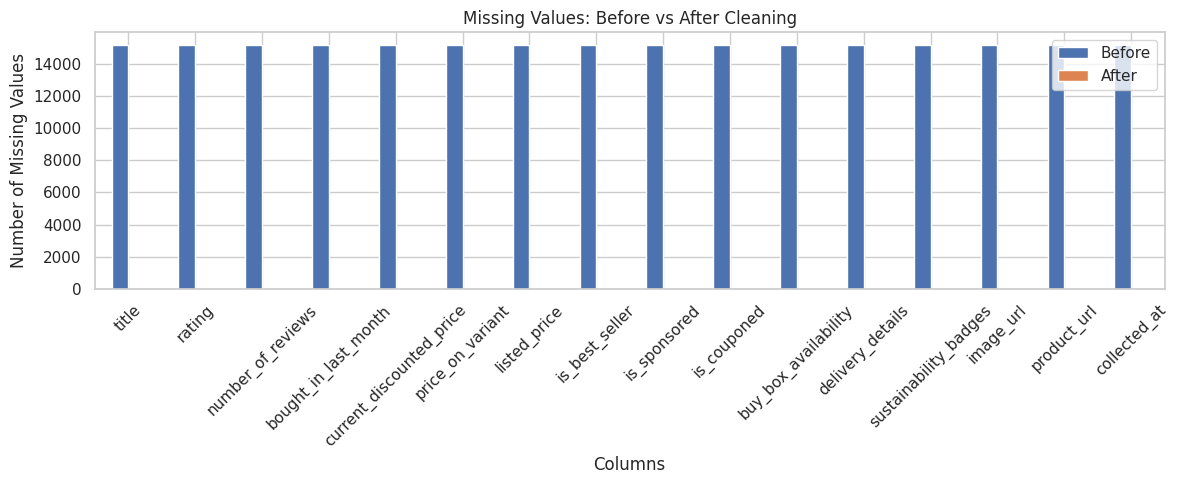

In [57]:
# STEP 17: Visualize missing values
missing_comparison = pd.DataFrame({
    "Before": missing_before.sum(),
    "After": df.isnull().sum()
})

missing_comparison = missing_comparison[
    (missing_comparison["Before"] > 0) |
    (missing_comparison["After"] > 0)
]

if not missing_comparison.empty:

    missing_comparison.plot(
        kind="bar",
        figsize=(12, 5)
    )

    plt.title("Missing Values: Before vs After Cleaning")
    plt.xlabel("Columns")
    plt.ylabel("Number of Missing Values")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Additional useful visualization: correlation heatmap
if len(numeric_columns) >= 2:

    plt.figure(figsize=(10, 7))

    sns.heatmap(
        df[numeric_columns].corr(),
        annot=True,
        cmap="coolwarm",
        fmt=".2f"
    )

    plt.title("Correlation Between Numerical Variables")
    plt.tight_layout()
    plt.show()

In [58]:
# STEP 19: Generate useful insights
print("\n========== KEY DATA QUALITY INSIGHTS ==========")

print(f"Original rows: {before_rows}")
print(f"Final rows: {after_rows}")
print(f"Duplicate rows removed: {duplicates_removed}")
print(f"Missing values before cleaning: {missing_before.sum()}")
print(f"Missing values after cleaning: {df.isnull().sum().sum()}")

if len(numeric_columns) > 0:

    print("\nNumerical variable summary:")

    for col in numeric_columns:

        print(
            f"{col}: "
            f"Min={df[col].min():.2f}, "
            f"Median={df[col].median():.2f}, "
            f"Max={df[col].max():.2f}"
        )

print("\nData cleaning completed successfully.")


========== KEY DATA QUALITY INSIGHTS ==========
Original rows: 8127
Final rows: 7855
Duplicate rows removed: 272
Missing values before cleaning: 15193
Missing values after cleaning: 0

Numerical variable summary:
number_of_reviews: Min=1.00, Median=1059.50, Max=12382.50

Data cleaning completed successfully.


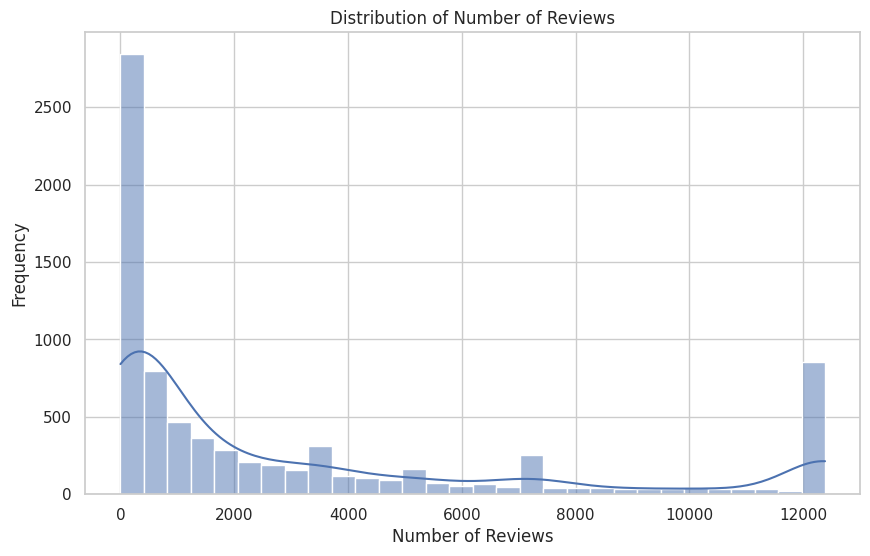

In [69]:
# Useful visualizations

# Ensure 'rating' is numerical for better visualization
# Extract numerical part from 'rating' column
if 'rating' in df.columns and df['rating'].dtype == 'string':
    df['numeric_rating'] = df['rating'].str.extract('([\d\.]+)').astype(float)
    df['numeric_rating'] = df['numeric_rating'].fillna(df['numeric_rating'].median()) # fill missing if any after extraction
else:
    # If 'rating' column is not a string type, assume it's already numeric or handle as appropriate
    # For this dataset, we expect 'rating' to be an object (string) initially.
    # If it's already numeric, no extraction needed. If missing, numeric_rating will remain None.
    if 'rating' in df.columns and pd.api.types.is_numeric_dtype(df['rating']):
        df['numeric_rating'] = df['rating']
    else:
        df['numeric_rating'] = None # Fallback if 'rating' column is not present or not convertible

# 1. Distribution of 'number_of_reviews'
if 'number_of_reviews' in df.columns and pd.api.types.is_numeric_dtype(df['number_of_reviews']):
    plt.figure(figsize=(10, 6))
    sns.histplot(df['number_of_reviews'], bins=30, kde=True)
    plt.title('Distribution of Number of Reviews')
    plt.xlabel('Number of Reviews')
    plt.ylabel('Frequency')
    plt.show()


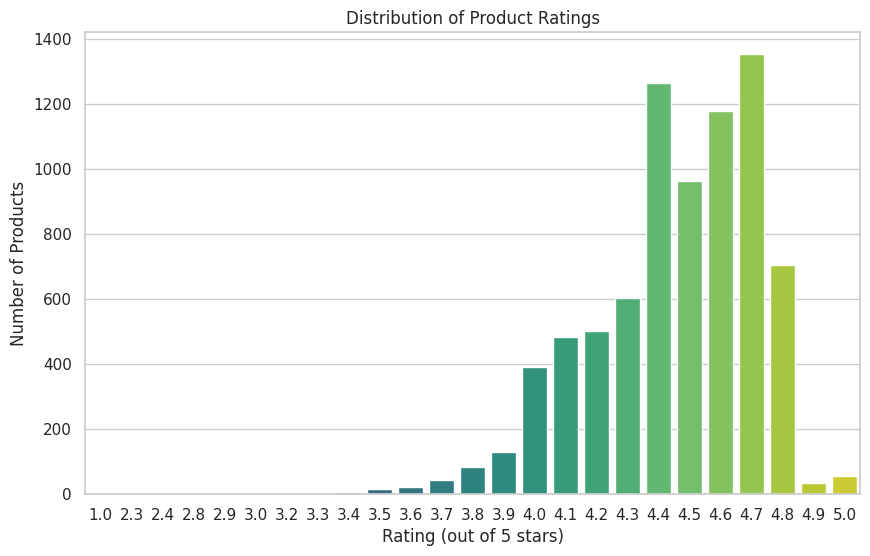

In [70]:
# 2. Distribution of 'numeric_rating'
if df['numeric_rating'] is not None and pd.api.types.is_numeric_dtype(df['numeric_rating']):
    plt.figure(figsize=(10, 6))
    sns.countplot(x=df['numeric_rating'].round(1).sort_values(), palette='viridis')
    plt.title('Distribution of Product Ratings')
    plt.xlabel('Rating (out of 5 stars)')
    plt.ylabel('Number of Products')
    plt.show()

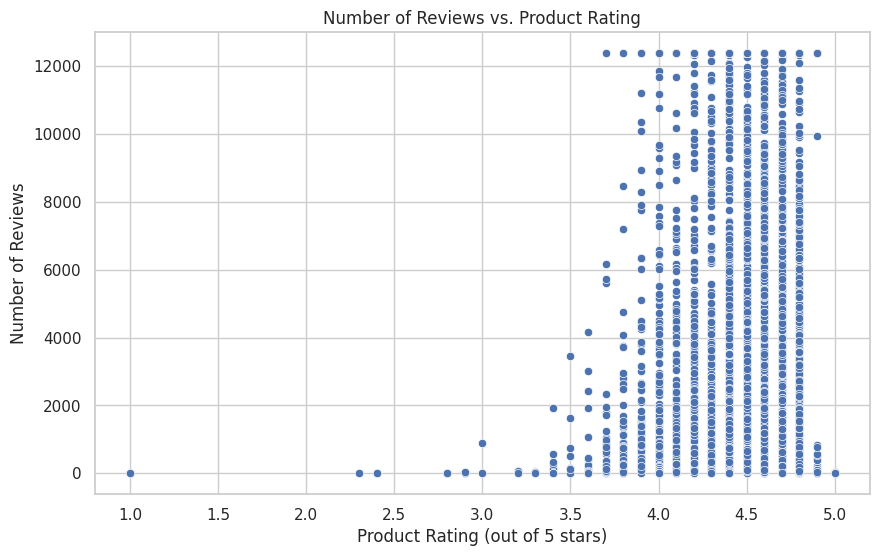

In [68]:
# 3. Scatter plot: Number of Reviews vs Rating
if 'number_of_reviews' in df.columns and df['numeric_rating'] is not None and \
   pd.api.types.is_numeric_dtype(df['number_of_reviews']) and pd.api.types.is_numeric_dtype(df['numeric_rating']):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='numeric_rating', y='number_of_reviews', data=df)
    plt.title('Number of Reviews vs. Product Rating')
    plt.xlabel('Product Rating (out of 5 stars)')
    plt.ylabel('Number of Reviews')
    plt.show()

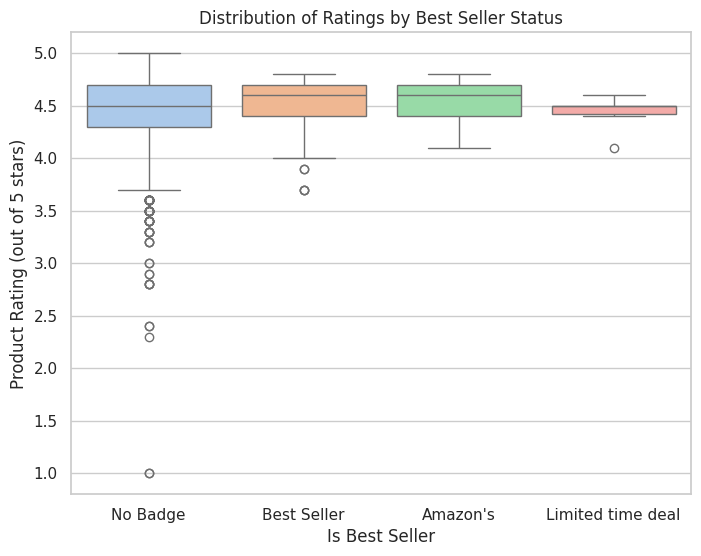

In [71]:
# Segmented analysis: Ratings by 'is_best_seller' status

if 'numeric_rating' in df.columns and 'is_best_seller' in df.columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='is_best_seller', y='numeric_rating', data=df, palette='pastel')
    plt.title('Distribution of Ratings by Best Seller Status')
    plt.xlabel('Is Best Seller')
    plt.ylabel('Product Rating (out of 5 stars)')
    plt.show()
else:
    print("Cannot perform segmented analysis: 'numeric_rating' or 'is_best_seller' columns not found.")

In [65]:
print("\nDescriptive statistics for the cleaned dataset:")
display(df.describe(include='all').T)


Descriptive statistics for the cleaned dataset:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
title,7855,6315,"Sanus Height Adjustable Speaker Stand for Sonos Era 300™ - 17"" Height Adjustment Sonos Stand Inc...",206,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,7855,25,4.7 out of 5 stars,1352,NaN,NaN,NaN,NaN,NaN,NaN,NaN
number_of_reviews,7855.0,<NA>,<NA>,<NA>,3169.630999,4102.142209,1.0,196.0,1059.5,4724.5,12382.5
bought_in_last_month,7855,42,1K+ bought in past month,1871,NaN,NaN,NaN,NaN,NaN,NaN,NaN
current_discounted_price,7855,1959,179.99,2307,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price_on_variant,7855,2687,basic variant price: nan,3604,NaN,NaN,NaN,NaN,NaN,NaN,NaN
listed_price,7855,751,No Discount,5475,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_best_seller,7855,4,No Badge,7512,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_sponsored,7855,2,Organic,6246,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_couponed,7855,28,No Coupon,7378,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [66]:
# Identify top 10 products by 'number_of_reviews'
if 'number_of_reviews' in df.columns:
    top_10_products = df.sort_values(by='number_of_reviews', ascending=False).head(10)
    print("\nTop 10 Products by Number of Reviews:")
    display(top_10_products[['title', 'number_of_reviews', 'numeric_rating']])
else:
    print("The 'number_of_reviews' column was not found in the dataset.")


Top 10 Products by Number of Reviews:


,title,number_of_reviews,numeric_rating
15,"Texas Instruments TI-30XIIS Scientific Calculator, Black with Blue Accents",12382.5,4.7
10,"Amazon Basics 48-Pack AA Alkaline High-Performance Batteries, 1.5 Volt, 10-Year Shelf Life",12382.5,4.7
3,"Apple AirPods Pro 2 Wireless Earbuds, Active Noise Cancellation, Hearing Aid Feature, Bluetooth ...",12382.5,4.6
23,"Apple EarPods Headphones with USB-C Plug, Wired Ear Buds with Built-in Remote to Control Music, ...",12382.5,4.6
22,"Amazon Basics Wood-Cased #2 Pencils, Pre-sharpened, HB Lead Bulk Box, 150 Count, Yellow",12382.5,4.8
7830,"Apple iPhone XS Max, 64GB, Space Gray - Fully Unlocked (Renewed)",12382.5,4.3
862,"Amazon Basics Classic Lined Notebook, 240 Pages Hardcover, 5 x 8.25-Inch, Black",12382.5,4.7
902,"Apple iPhone 12 Mini, 64GB, Black - Unlocked (Renewed)",12382.5,4.0
907,"HP 902 Black Ink Cartridge for HP Printers | Works with Printer Series: OfficeJet 6950, 6960; Of...",12382.5,4.5
877,"Amazon 9W Official OEM USB Charger and Power Adapter for Fire Tablets, Kindle eReaders, and Echo...",12382.5,4.7


In [59]:
# STEP 20: Save cleaned dataset
OUTPUT_FILE = "cleaned_dataset.csv"

df.to_csv(
    OUTPUT_FILE,
    index=False
)

print(f"\nCleaned dataset saved as: {OUTPUT_FILE}")
print("Final shape:", df.shape)


Cleaned dataset saved as: cleaned_dataset.csv
Final shape: (7855, 16)
